<a href="https://www.kaggle.com/code/sonawanelalitsunil/ford-car-price-estimation-using-ml-xgb-93-23?scriptVersionId=224219714" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ford-car-price-prediction/ford.csv


## Title: Ford Car Price Estimation Using Machine Learning

Description

This project focuses on predicting the resale price of Ford cars using machine learning techniques. The dataset includes various features such as manufacturing year, engine capacity, mileage, fuel type, owner type, insurance status, and other relevant attributes. The goal is to build a robust predictive model that helps users estimate the expected resale price of a Ford car based on historical sales data.

Key Steps in the Project:


Exploratory Data Analysis (EDA)

Data cleaning and handling missing values

Visualizing price distribution and correlations between features

Identifying key factors affecting resale prices

Feature Engineering & Encoding

Converting categorical variables (e.g., fuel type, owner type) into numerical representations

Creating new meaningful features if necessary

Train-Test Splitting


Splitting the dataset into training and testing sets to evaluate model performance

Applying Machine Learning Algorithms

Linear Regression

Decision Tree Regressor

Random Forest Regressor

Gradient Boosting Machines (GBM)

XGBoost

Support Vector Machine (SVM)

Neural Networks

Model Evaluation

Comparing models based on performance metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score

Selecting the best-performing model for accurate price estimation

Data Visualization

Graphical representations of model performance in percentage

Feature importance analysis to understand key price-influencing factors

## Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/ford-car-price-prediction/ford.csv")

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [7]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [8]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17961    False
17962    False
17963    False
17964    False
17965    False
Length: 17966, dtype: bool

In [10]:
df.corr

<bound method DataFrame.corr of          model  year  price transmission  mileage fuelType  tax   mpg  \
0       Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7   
1        Focus  2018  14000       Manual     9083   Petrol  150  57.7   
2        Focus  2017  13000       Manual    12456   Petrol  150  57.7   
3       Fiesta  2019  17500       Manual    10460   Petrol  145  40.3   
4       Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7   
...        ...   ...    ...          ...      ...      ...  ...   ...   
17961    B-MAX  2017   8999       Manual    16700   Petrol  150  47.1   
17962    B-MAX  2014   7499       Manual    40700   Petrol   30  57.7   
17963    Focus  2015   9999       Manual     7010   Diesel   20  67.3   
17964       KA  2018   8299       Manual     5007   Petrol  145  57.7   
17965    Focus  2015   8299       Manual     5007   Petrol   22  57.7   

       engineSize  
0             1.0  
1             1.0  
2             1.0  
3          

In [11]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

## Visualization

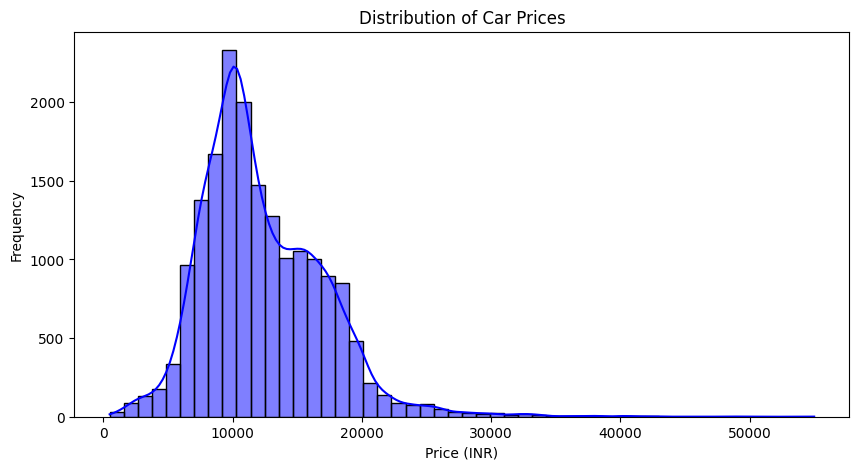

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color="blue")
plt.title('Distribution of Car Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

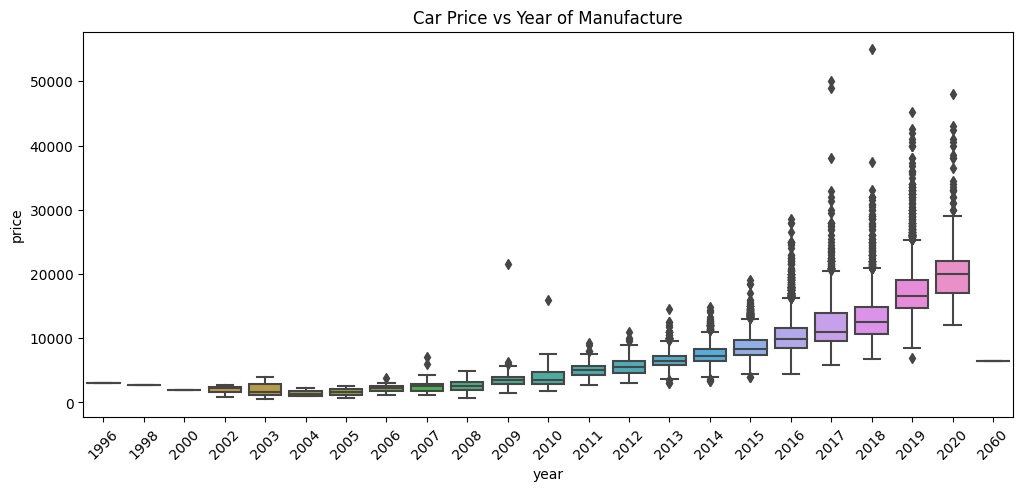

In [13]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='year', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Car Price vs Year of Manufacture')
plt.show()

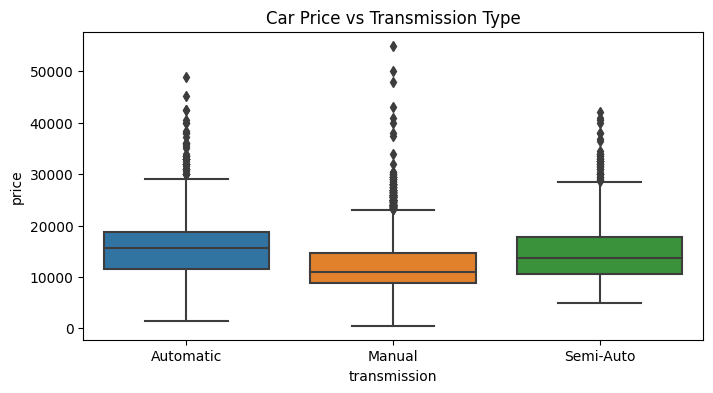

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='transmission', y='price', data=df)
plt.title('Car Price vs Transmission Type')
plt.show()

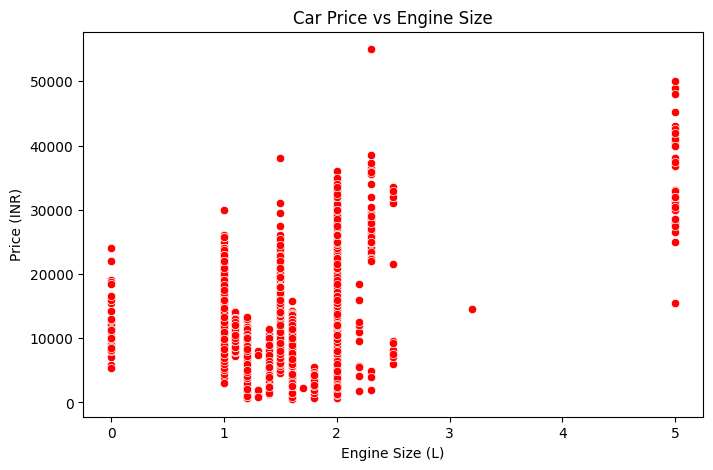

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='engineSize', y='price', data=df, color='red')
plt.title('Car Price vs Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (INR)')
plt.show()

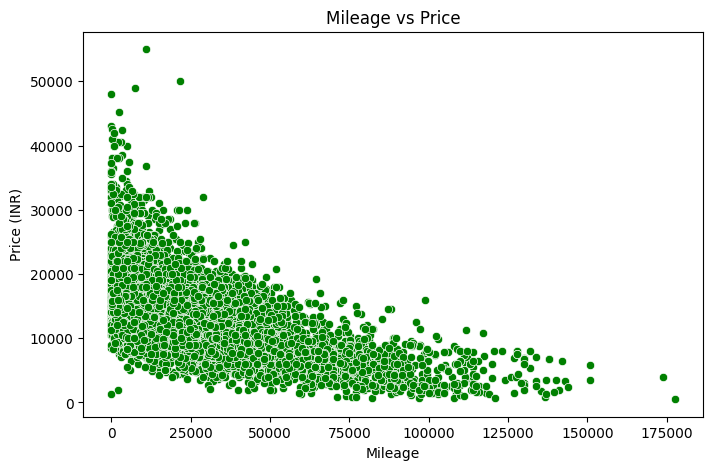

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='mileage', y='price', data=df, color='green')
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price (INR)')
plt.show()

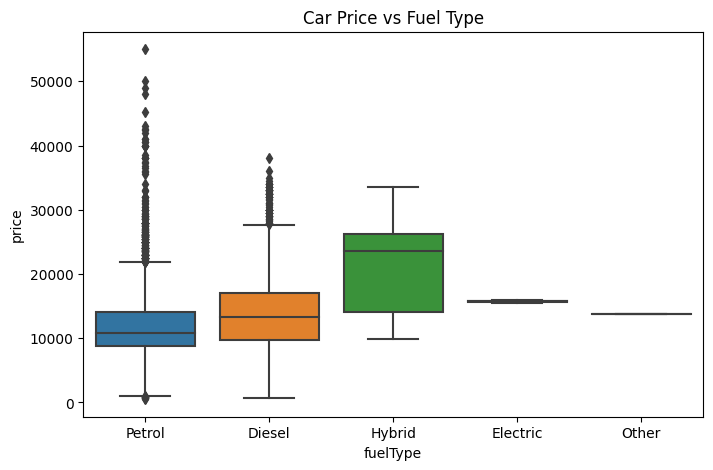

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='fuelType', y='price', data=df)
plt.title('Car Price vs Fuel Type')
plt.show()

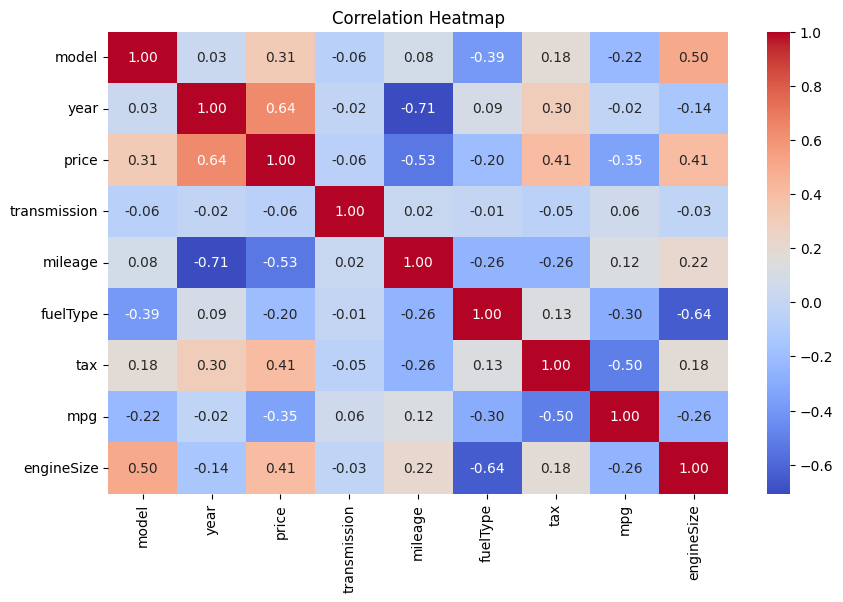

In [18]:
# Convert categorical variables to numeric using Label Encoding
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['model', 'transmission', 'fuelType']

df_encoded = df.copy()
encoder = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

# Now generate the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## EDA

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


None

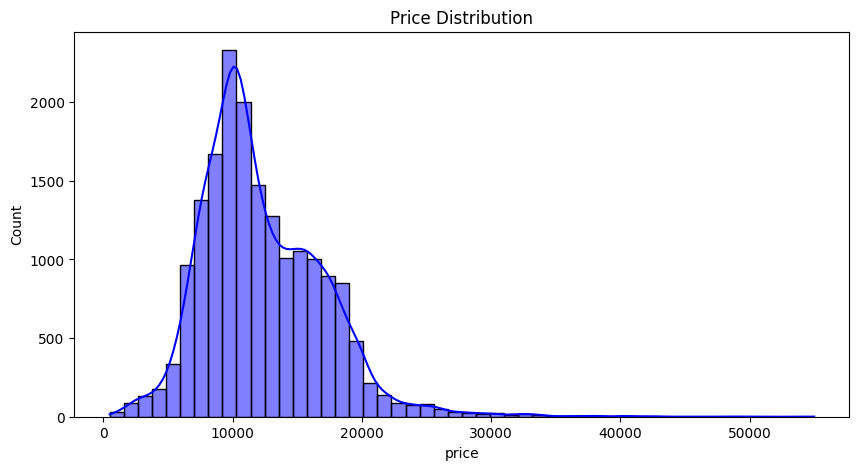

Linear Regression - MAE: 1776.83, MSE: 5903593.74, R2: 73.66%
Decision Tree - MAE: 1054.62, MSE: 2499686.06, R2: 88.85%
Random Forest - MAE: 867.29, MSE: 1605119.23, R2: 92.84%
Gradient Boosting - MAE: 1094.87, MSE: 2384773.82, R2: 89.36%
XGBoost - MAE: 853.40, MSE: 1516363.01, R2: 93.23%
Support Vector Machine - MAE: 3182.51, MSE: 19086969.16, R2: 14.84%
Neural Network - MAE: 1040.75, MSE: 2151378.95, R2: 90.40%


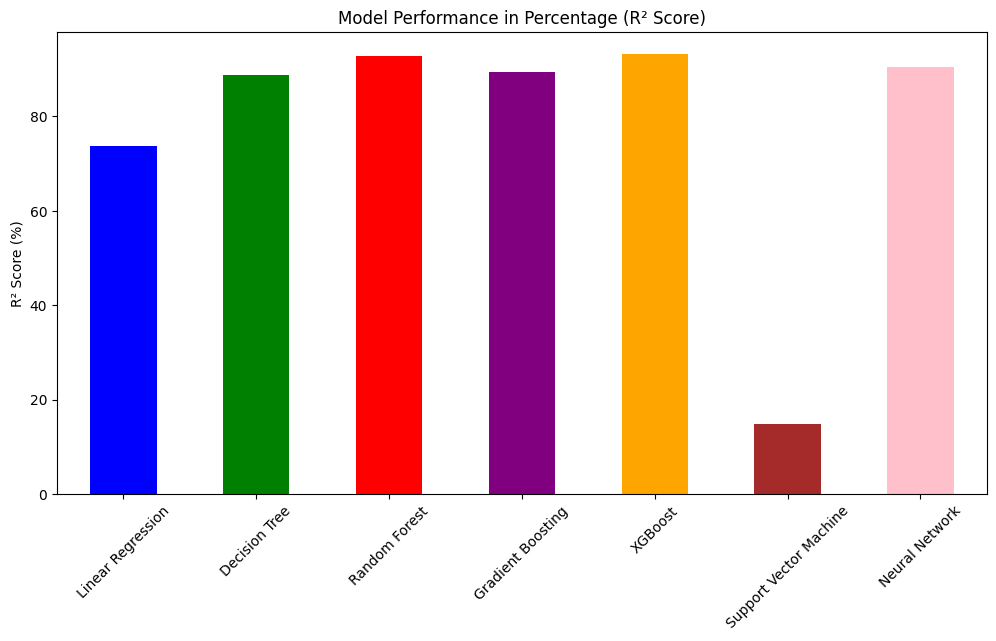

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

display(df.head())
display(df.info())

df = df.dropna()

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Price Distribution')
plt.show()

# Encoding categorical variables
label_encoders = {}
categorical_cols = ['model', 'transmission', 'fuelType']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Feature Selection
X = df.drop(columns=['price'])
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Dictionary to store results
results = {}

# Function to evaluate model
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'MSE': mse, 'R2 Score': r2 * 100}
    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, R2: {r2:.2%}")

evaluate_model(LinearRegression(), "Linear Regression")
evaluate_model(DecisionTreeRegressor(), "Decision Tree")
evaluate_model(RandomForestRegressor(n_estimators=50), "Random Forest")
evaluate_model(GradientBoostingRegressor(n_estimators=50), "Gradient Boosting")
evaluate_model(XGBRegressor(n_estimators=50, learning_rate=0.1), "XGBoost")
evaluate_model(SVR(), "Support Vector Machine")
evaluate_model(MLPRegressor(hidden_layer_sizes=(50,50), max_iter=500), "Neural Network")

# Convert results into DataFrame
results_df = pd.DataFrame(results).T

# Visualization of model performance
plt.figure(figsize=(12, 6))
results_df['R2 Score'].plot(kind='bar', color=['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink'])
plt.title("Model Performance in Percentage (R² Score)")
plt.ylabel("R² Score (%)")
plt.xticks(rotation=45)
plt.show()

# Thank you....pls upvote!!!